In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC,SVC
from sklearn.metrics import f1_score,make_scorer
from sklearn.ensemble import RandomForestClassifier
import shap

from project_package.visualization import Model_Visualizer
from project_package import utility,evaluation

Regression test

In [2]:
test_data = utility.generate_data('diabetes',0.2,seed=0)
X_train, X_test, y_train, y_test = utility.generate_data('diabetes',0.2,seed=0,binary_label=True) 

In [3]:
feature_labels = utility.get_feature_labels('diabetes')
reg_vis_obj = Model_Visualizer(*test_data,feature_names=feature_labels)
ridge = Ridge(alpha=1).fit(X_train, y_train)

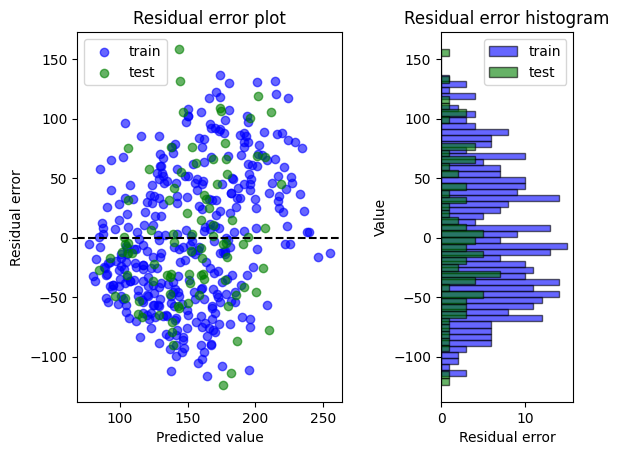

In [4]:
reg_vis_obj.residual_plot(ridge,bins=50)

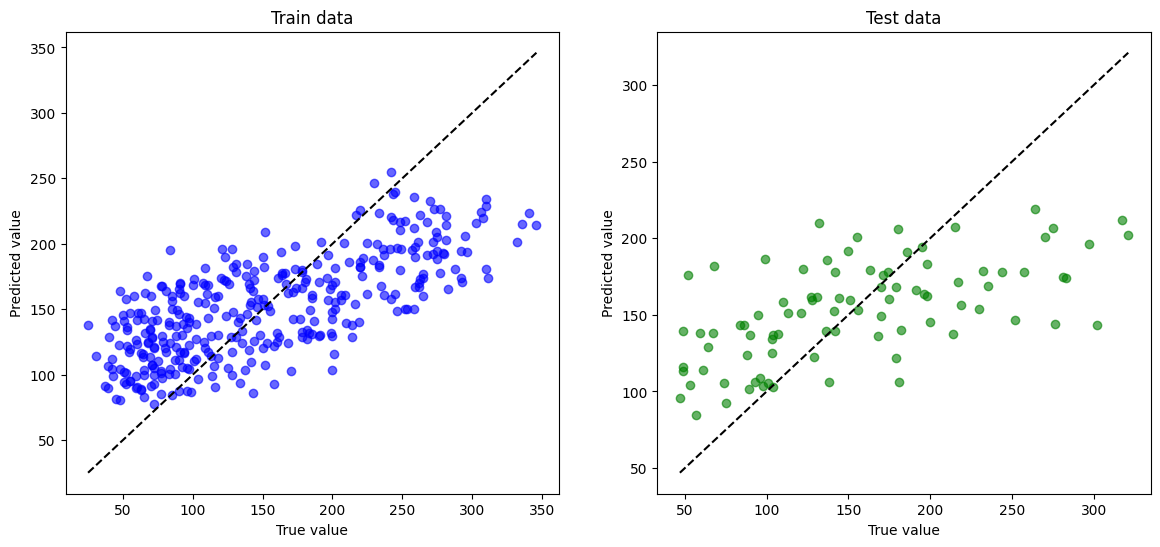

In [5]:
reg_vis_obj.prediction_validate_plot(ridge)

Classification test

In [14]:
test_data = utility.generate_data('cancer',0.3,seed=0,binary_label=True,add_random=False)
X_train, X_test, y_train, y_test = utility.generate_data('cancer',0.3,seed=0,binary_label=True,add_random=False) 

feature_labels = utility.get_feature_labels('cancer')
classify_vis_obj = Model_Visualizer(*test_data,feature_names=feature_labels)


classifier = make_pipeline(StandardScaler(), SVC(kernel='linear',random_state=0,probability=True))
# classifier = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=0))

classifier.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(kernel='linear', probability=True, random_state=0))])

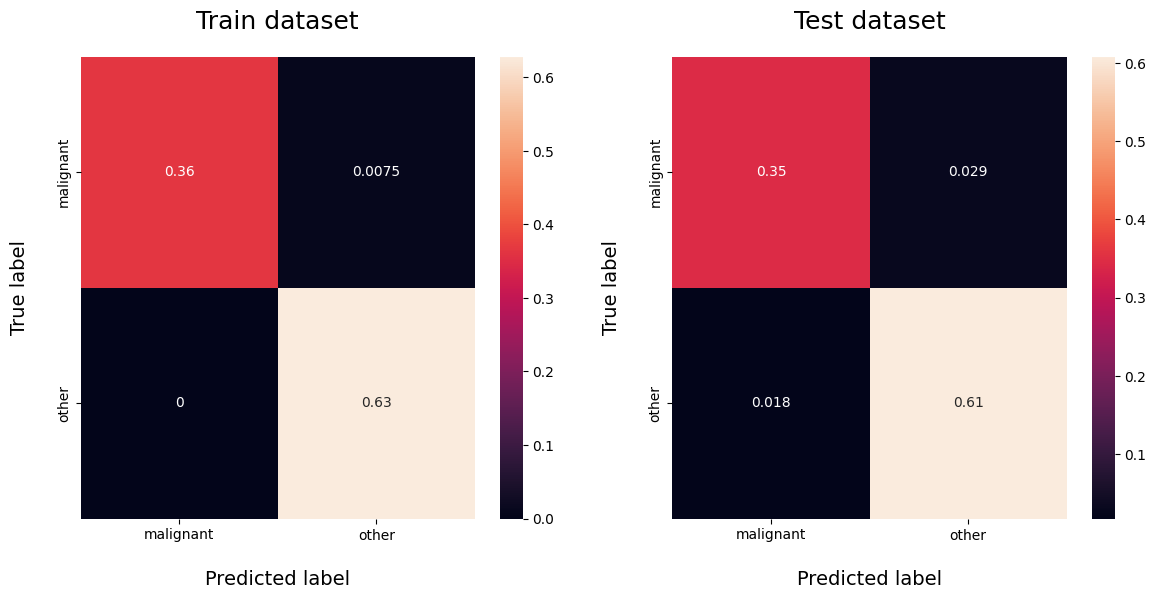

In [15]:
classify_vis_obj.confusion_matrix(classifier,utility.get_target_labels('cancer',binary_label=True),normalize=True)

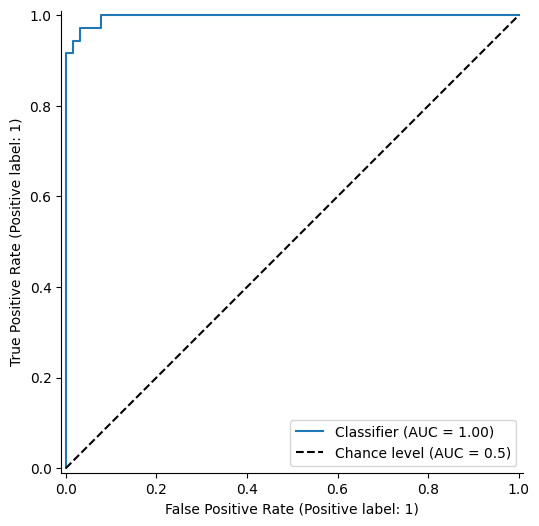

In [16]:
classify_vis_obj.ROC_curve(y_test = y_test,y_score = classifier.decision_function(X_test))

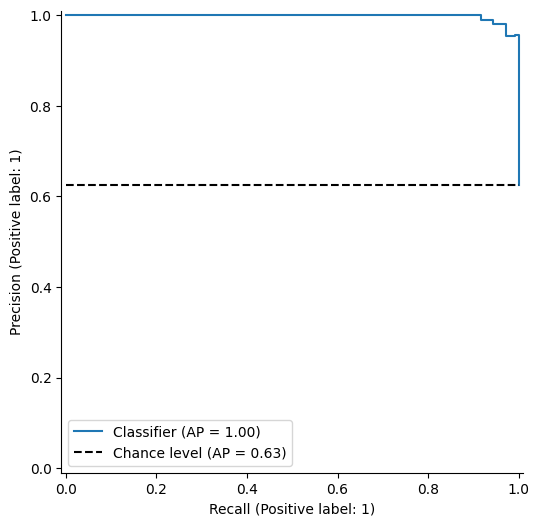

In [17]:
classify_vis_obj.precision_recall_curve(y_test = y_test,y_score = classifier.decision_function(X_test))

Feature Importance and Ablation Analysis

<Axes: title={'center': 'Feature Importance plot'}, xlabel='Importance', ylabel='Features'>

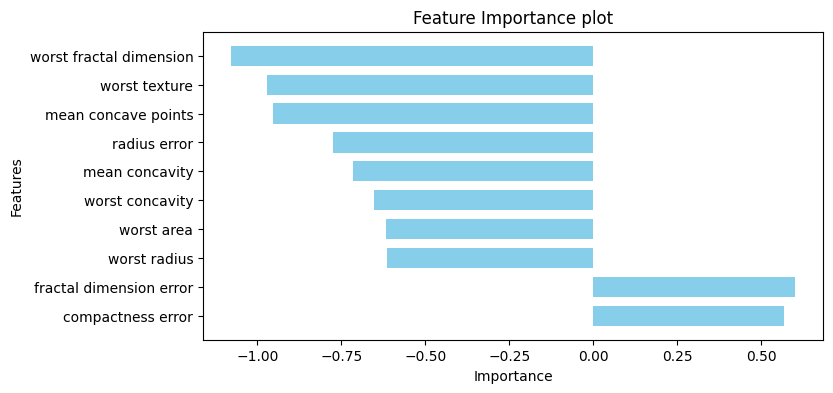

In [10]:
classify_vis_obj.feature_importance_plot(classifier.named_steps['svc'].coef_[0],normalize=False,top_n=10)

In [11]:
train_df,test_df = classify_vis_obj.reconstruct_dataframe()

train_permute,test_permute = evaluation.permutation_test(
    classifier,train_df,test_df,
    target_col = 'target_variable',scorer='f1_macro'
    )

<Axes: title={'center': 'train data'}, xlabel='Decrease in metric score'>

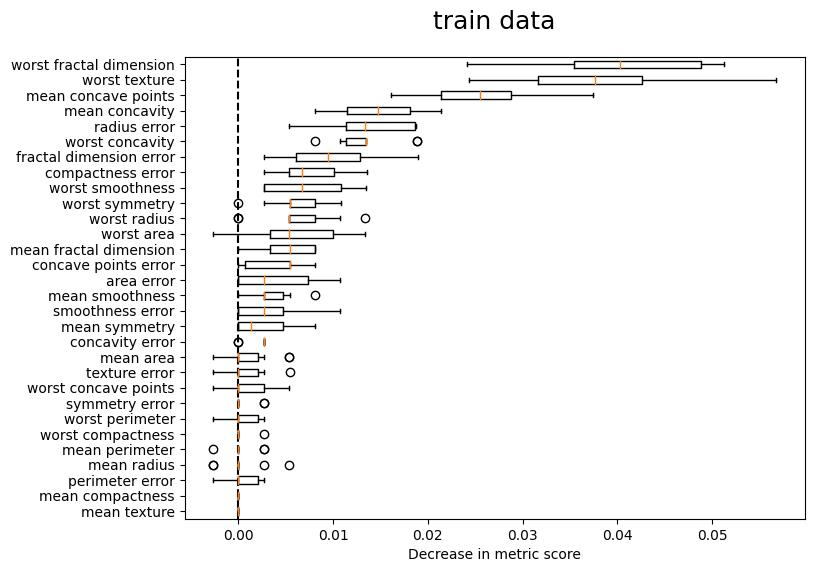

In [12]:
classify_vis_obj.permutation_importance_plot(train_permute,figsize=(8,6),title='train data')

<Axes: title={'center': 'test data'}, xlabel='Decrease in metric score'>

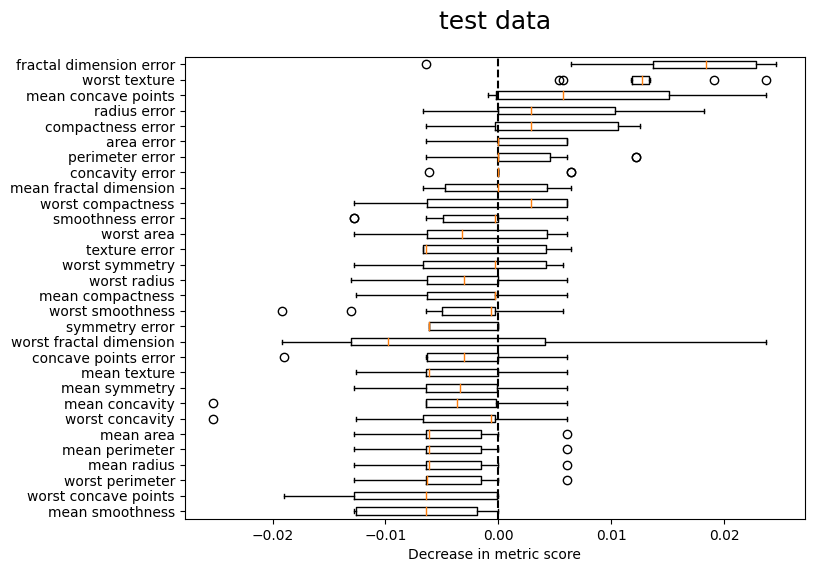

In [13]:
classify_vis_obj.permutation_importance_plot(test_permute,figsize=(8,6),title='test data')

<Axes: title={'center': 'Ablation test'}, xlabel='f1 score'>

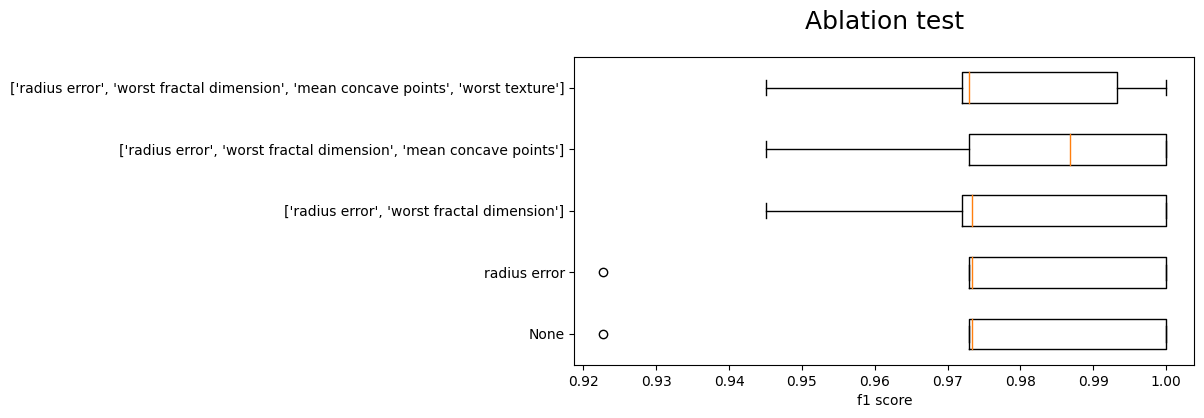

In [14]:
remove_features = ['radius error',
                    ['radius error','worst fractal dimension'],
                    ['radius error','worst fractal dimension','mean concave points'],
                    ['radius error','worst fractal dimension','mean concave points','worst texture']
                    ]

score_array,eval_df = evaluation.ablation_test(
    classifier,
    train_data = train_df,
    test_data = test_df,
    target_col = 'target_variable',
    scorer=make_scorer(f1_score,average='macro'),
    remove_features = remove_features
)

classify_vis_obj.box_plot(score_array.T,labels=['None'] + remove_features,title='Ablation test',xlabel='f1 score')

Sensitivity Analysis

In [15]:
grids = {
    'svc__C':np.logspace(-3,6,10),
    'svc__gamma':np.logspace(-4,7,12)
    }
# grids = {'svc__C':np.linspace(0.01,1000,15),'svc__gamma':np.linspace(0.01,1000,10)}
eval_df = evaluation.supervised_sensivity_test(
    classifier,train_df,
    target_col='target_variable',
    param_grid=grids,
    # scoring={'r2':'r2','f1_macro':'f1_macro'}
    scoring = 'f1_macro'
    )
eval_df

,svc__C,svc__gamma,f1_macro,f1_macro_std
0,0.001,1.000000e-04,0.929756,0.041272
1,0.001,1.000000e-03,0.929756,0.041272
2,0.001,1.000000e-02,0.929756,0.041272
3,0.001,1.000000e-01,0.929756,0.041272
4,0.001,1.000000e+00,0.929756,0.041272
...,...,...,...,...
115,1000000.000,1.000000e+03,0.936662,0.034772
116,1000000.000,1.000000e+04,0.936662,0.034772
117,1000000.000,1.000000e+05,0.936662,0.034772
118,1000000.000,1.000000e+06,0.936662,0.034772


In [16]:
classify_vis_obj.sensivity_plot(eval_df,
               'f1_macro',
               param1 = ('svc__C','svc__gamma',eval_df.svc__gamma.unique()[0]),
               param2 = ('svc__gamma','svc__C',eval_df.svc__C.unique()[7])
               )

Learning curve

In [17]:
cross_scores,sample_range,result_df = evaluation.learning_curve_test(
    classifier,train_df,
    target_col='target_variable',
    sample_range=np.linspace(20,390,38).astype(int),
    scorer = make_scorer(f1_score,average='macro')
    )

<Axes: title={'center': 'Learning curve analysis'}, xlabel='No. of training records', ylabel='F1 score'>

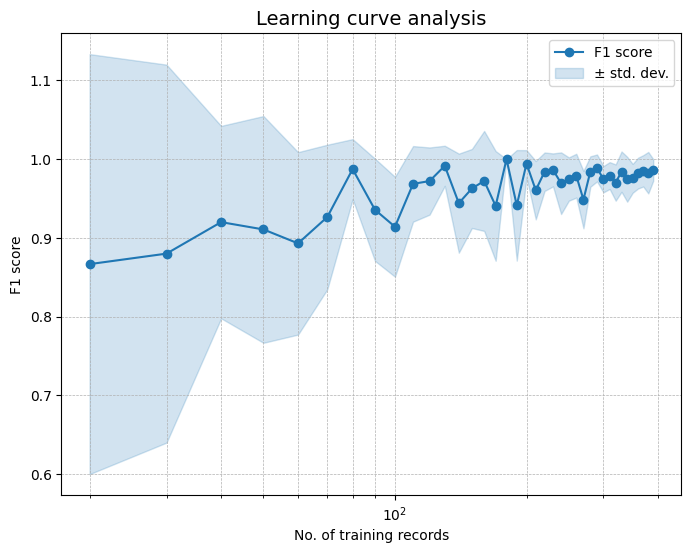

In [18]:
classify_vis_obj.learning_curve_plot(sample_range,result_df.score_mean,result_df.score_std,log_sample=True)

Failure analysis (regression)

In [19]:
train_df,test_df = reg_vis_obj.reconstruct_dataframe()

ex_df,ex_info_df = evaluation.get_worst_examples(
    ridge,test_df,
    target_col='target_variable',
    problem_type='regression',
    get_random_err=False,
    random_state=0
)

test_shap_values,_ = evaluation.shap_analysis(
    ridge,
    shap.LinearExplainer,
    train_df,
    test_df
)

ex_shap_values,_ = evaluation.shap_analysis(
    ridge,
    shap.LinearExplainer,
    train_df,
    ex_df,
)


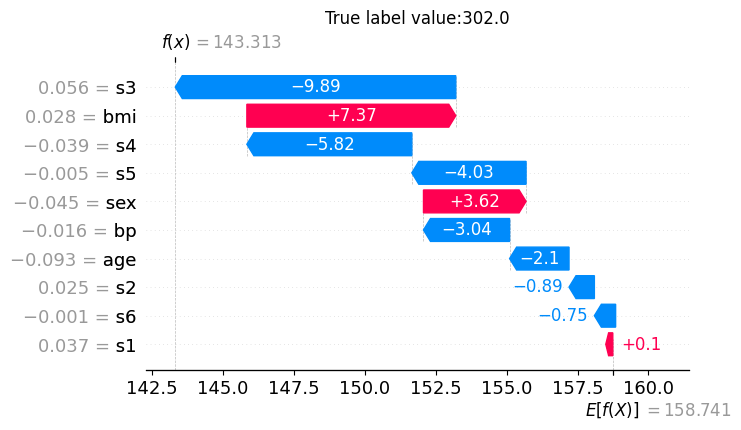

In [20]:
reg_vis_obj.waterfall_plot(
    ex_shap_values[0],
    title = f'True label value:{ex_df.target_variable.iloc[0]}',
    figsize=(7,4)
    )

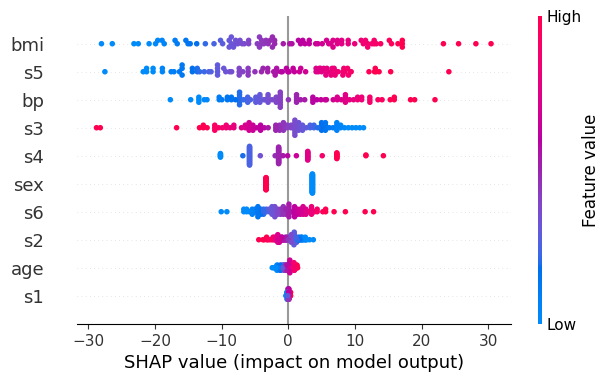

In [21]:
reg_vis_obj.beeswarm_plot(
    test_shap_values,
    figsize=(7,4)
    )

Failure analysis (classification)

In [ ]:
train_df,test_df = classify_vis_obj.reconstruct_dataframe()

ex_df,ex_info_df = evaluation.get_worst_examples(
    classifier,test_df,
    get_n=1,
    target_col='target_variable',
    problem_type='classification',
    get_random_err=False,
    random_state=0
)

test_shap_values,_ = evaluation.shap_analysis(
    classifier,
    shap.LinearExplainer,
    train_df,
    test_df
)

ex_shap_values,_ = evaluation.shap_analysis(
    classifier,
    shap.LinearExplainer,
    train_df,
    ex_df,
)


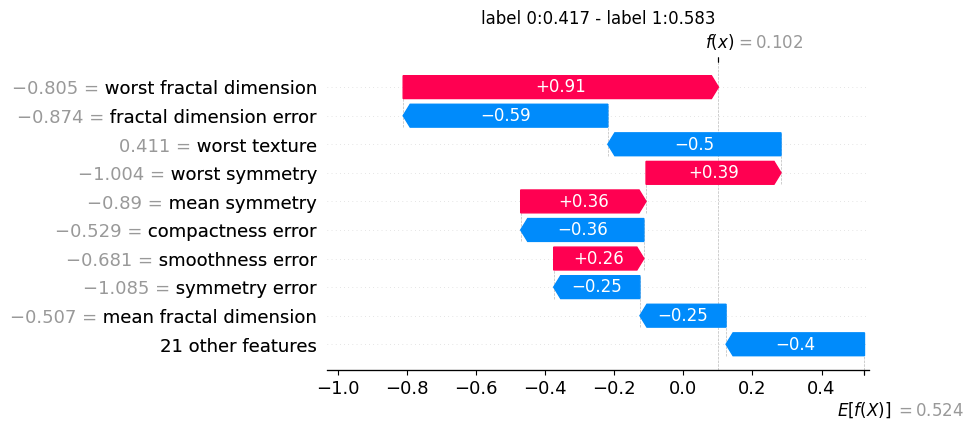

In [21]:
classify_vis_obj.waterfall_plot(
    ex_shap_values[1],
    title = f'label 0:{round(ex_info_df.probability_0.iloc[1],3)} - label 1:{round(ex_info_df.probability_1.iloc[1],3)}',
    figsize=(7,4)
    )

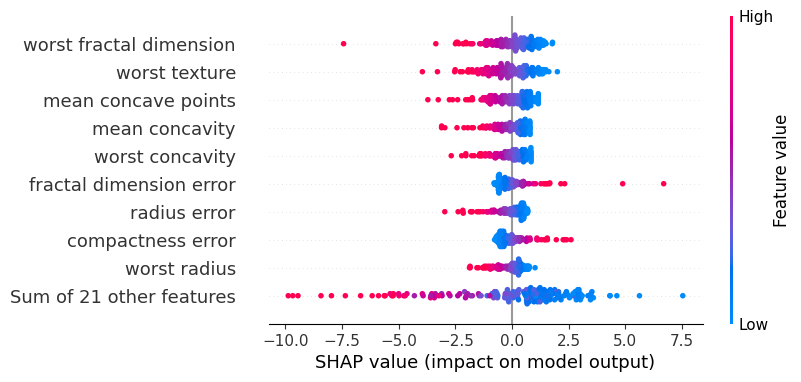

In [24]:
classify_vis_obj.beeswarm_plot(
    test_shap_values,
    figsize=(7,4)
    )

testing pycaret (not used)

In [ ]:
from pycaret import regression
from pycaret import classification
from sklearn import datasets
import plotly.express as px
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
data = px.data.iris()
data.drop('species_id',axis=1,inplace=True)

In [ ]:
train_idx,test_idx = train_test_split(np.arange(data.shape[0]),test_size=0.3,stratify=data.species,random_state=0)

In [ ]:
train_data = data.iloc[train_idx].reset_index(drop=True)
test_data = data.iloc[test_idx].reset_index(drop=True)

In [ ]:
classification.get_config('dataset_transformed')

,sepal_length,sepal_width,petal_length,petal_width,species
0,0.975431,0.569896,1.080800,1.703073,2
1,2.141950,1.673939,1.637094,1.310056,2
2,0.625476,0.349088,0.858283,1.441062,2
3,-1.474257,1.232322,-1.533783,-1.310056,0
4,-0.774346,0.790705,-1.311265,-1.310056,0
...,...,...,...,...,...
145,-0.424390,1.011514,-1.366894,-1.310056,0
146,1.558691,1.232322,1.303318,1.703073,2
147,-1.474257,0.128279,-1.255635,-1.310056,0
148,-1.240953,-0.092529,-1.311265,-1.441062,0


In [ ]:
classification.setup(data=train_data, target='species',test_data=test_data,index=False,normalize=False,fold=4)

,Description,Value
0,Session id,2568
1,Target,species
2,Target type,Multiclass
3,Target mapping,"setosa: 0, versicolor: 1, virginica: 2"
4,Original data shape,"(150, 5)"
5,Transformed data shape,"(150, 5)"
6,Transformed train set shape,"(105, 5)"
7,Transformed test set shape,"(45, 5)"
8,Numeric features,4
9,Preprocess,True


In [ ]:
# custom_model = classification.create_model(LinearSVC())
custom_model = classification.create_model(classifier)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9231,0.0000,0.9231,0.9231,0.9231,0.8844,0.8844
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9615,0.0000,0.9615,0.9654,0.9613,0.9421,0.9442
Mean,0.9712,0.0000,0.9712,0.9721,0.9711,0.9566,0.9572
Std,0.0319,0.0000,0.0319,0.0316,0.0319,0.0479,0.0478


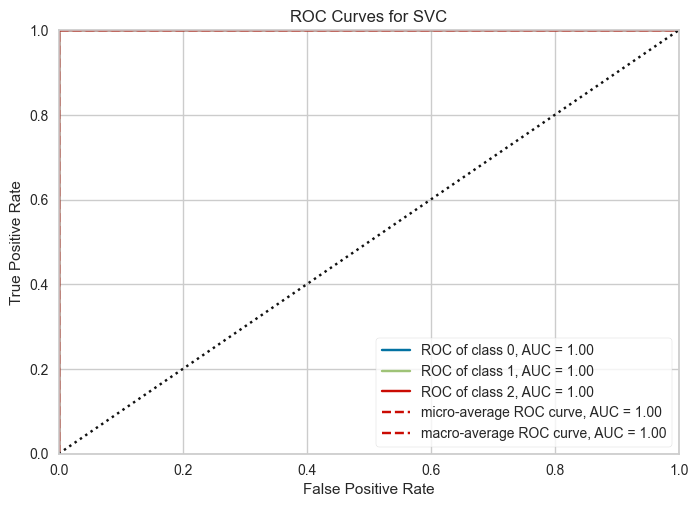

In [ ]:
classification.plot_model(custom_model, plot='auc')